In [1]:
from langchain_ollama import ChatOllama, OllamaEmbeddings
from langchain_core.prompts import ChatPromptTemplate
from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_chroma import Chroma
from langchain_core.documents import Document
from langgraph.graph import StateGraph,START,END,MessagesState

In [2]:
# Load the pdf documents
loader = PyPDFLoader("./documents/evs_oil_price_shock.pdf")
raw_docs = loader.load()
print(f"Loaded {len(raw_docs)} pages")

Loaded 15 pages


In [3]:
print(raw_docs[0].page_content)

Will EVs Dampen the Oil Price
 Shock?
Electric Vehicles, Oil Demand Destruction, and the Future of Energy Price
 Volatility
 Version 1.0   |   April 2026
 Technical Reference Document


In [4]:
print(raw_docs[3].page_content)

Will EVs Dampen the Oil Price Shock?
Version 1.0
Research Report — For Educational and RAG Pipeline Use
Page 4
1. Introduction
 Oil price shocks have long been recognized as among the most destabilizing forces in
modern economies. From the Arab oil embargo of 1973 and the Iranian Revolution supply
disruption of 1979, to the Gulf War spike of 1990, the demand-driven surge of 2007–2008,
and the supply collapse of 2020 triggered by the COVID-19 pandemic, each episode has
revealed the profound sensitivity of economic output, inflation, and political stability to
movements in the price of crude oil. Economists estimate that a sustained $10 per barrel
increase in oil prices reduces GDP growth in oil-importing nations by 0.2 to 0.5 percentage
points, while simultaneously raising consumer price indices and compressing corporate
margins across energy-intensive industries. The asymmetry of this exposure — importers
bear the brunt while exporters benefit — has also been a persistent source of geo

# Split Documents into chunks

In [5]:
splitter = RecursiveCharacterTextSplitter(chunk_size=900, chunk_overlap=150)
chunks = splitter.split_documents(raw_docs)

print(f"Split into {len(chunks)} chunks")

Split into 51 chunks


# Initialize the Embedding Model

In [6]:
embeddings = OllamaEmbeddings(model="embeddinggemma:300m")
# from langchain_openai import ChatOpenAI, OpenAIEmbeddings
# # initialize the embedding model
# embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

In [7]:
vector_store = Chroma(
    collection_name="rag_base",
    embedding_function=embeddings,
)

vector_store.add_documents(documents=chunks)

retriever = vector_store.as_retriever(search_kwargs={"k":4})
print("Vector store is ready")

Vector store is ready


# Graph State

In [8]:
class AgenticRAGState(MessagesState):
    
    query: str
    retrieved_docs: list[Document]
    context: str
    generation: str

In [9]:
# Initializing the llm

llm= ChatOllama(model="llama3.2:3b")
# initialize the LLM

# llm = ChatOpenAI(model="gpt-5-mini")

In [10]:
llm.invoke("Hi")

AIMessage(content='How can I assist you today?', additional_kwargs={}, response_metadata={'model': 'llama3.2:3b', 'created_at': '2026-05-24T19:48:44.459971Z', 'done': True, 'done_reason': 'stop', 'total_duration': 3530633750, 'load_duration': 2632875292, 'prompt_eval_count': 26, 'prompt_eval_duration': 235917167, 'eval_count': 8, 'eval_duration': 622801416, 'logprobs': None, 'model_name': 'llama3.2:3b', 'model_provider': 'ollama'}, id='lc_run--019e5b88-515e-7922-90c9-0ed54c515fdf-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 26, 'output_tokens': 8, 'total_tokens': 34})

In [11]:
# Retrievers relevant docs from the vector store

def retrieve(state: AgenticRAGState) -> dict:    
    
    docs = retriever.invoke(state["query"])
    
    context = "\n\n".join(doc.page_content for doc in docs)
    
    return {"retrieved_docs": docs, "context": context}

In [12]:
# generates response using the retrieved context
from langchain_core.prompts import ChatPromptTemplate

def generate(state: AgenticRAGState) -> dict:
    query = state["query"]
    context = state.get("context") or ""

    prompt_template = ChatPromptTemplate.from_messages([
        ("system", "Answer the question using only the context below.\n\nContext:\n{context}"),
        ("human", "{query}"),
    ])

    response = (prompt_template | llm).invoke({"context": context, "query": query})

    return {"generation": response.content}

In [13]:
# Build the graph

graph_builder = StateGraph(AgenticRAGState)

In [14]:
graph_builder.add_node("retrieve", retrieve)
graph_builder.add_node("generate", generate)

graph_builder.add_edge(START, "retrieve")
graph_builder.add_edge("retrieve","generate")
graph_builder.add_edge("generate",END)


In [15]:
graph = graph_builder.compile()

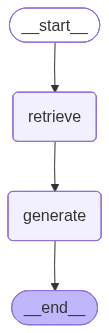

In [16]:
graph

In [17]:
test_query = "How will EVS impact oil demand in the next decade?"

result = graph.invoke({"query": test_query, "messages": []})

In [18]:
print("=== GENERATED RESPONSE ===")
print(result["generation"])

=== GENERATED RESPONSE ===
According to the report, EVs (Electric Vehicles) will shave meaningful but modest volumes from global oil demand growth, likely delaying rather than preventing demand peaks and offering only partial insulation against supply-driven price shocks. In the near term (through 2030), EV penetration is expected to reduce oil demand by a small amount.

However, over the 2030-2050 horizon, cumulative fleet electrification could reduce oil demand by 20 to 30 million barrels per day, which would be large enough to fundamentally restructure the oil supply curve and compress the oil price curve.


In [19]:
result

{'messages': [],
 'query': 'How will EVS impact oil demand in the next decade?',
 'retrieved_docs': [Document(id='3ad677e9-7da6-41ff-b1d2-f70520c9308c', metadata={'keywords': '', 'author': '(anonymous)', 'moddate': '2026-04-18T21:49:03+05:00', 'producer': 'ReportLab PDF Library - (opensource)', 'creationdate': '2026-04-18T21:49:03+05:00', 'title': '(anonymous)', 'page': 2, 'creator': '(unspecified)', 'subject': '(unspecified)', 'total_pages': 15, 'page_label': '3', 'source': './documents/evs_oil_price_shock.pdf', 'trapped': '/False'}, page_content='and cushion economies against future oil price shocks? This report examines that question\nfrom multiple angles, drawing on demand trajectory modeling, macroeconomic transmission\nmechanisms, producer response dynamics, and the structural limits of EV-led demand\ndestruction.\n The central finding of this analysis is nuanced. In the near term — through 2030 — EV\npenetration will shave meaningful but modest volumes from global oil demand gro

In [20]:
print("\n=== RETRIEVED DOCUMENTS ===")
for i, doc in enumerate(result["retrieved_docs"], 1):
    source = doc.metadata.get("source", "unknown")
    page = doc.metadata.get("page", "?")
    snippet = doc.page_content[:500].replace("\n", " ")
    print(f"[{i}] Source: {source} | Page: {page}")
    print(f"    {snippet}...")


=== RETRIEVED DOCUMENTS ===
[1] Source: ./documents/evs_oil_price_shock.pdf | Page: 2
    and cushion economies against future oil price shocks? This report examines that question from multiple angles, drawing on demand trajectory modeling, macroeconomic transmission mechanisms, producer response dynamics, and the structural limits of EV-led demand destruction.  The central finding of this analysis is nuanced. In the near term — through 2030 — EV penetration will shave meaningful but modest volumes from global oil demand growth, likely delaying rather than preventing demand peaks and...
[2] Source: ./documents/evs_oil_price_shock.pdf | Page: 13
    Will EVs Dampen the Oil Price Shock? Version 1.0 Research Report — For Educational and RAG Pipeline Use Page 14  For policymakers in oil-importing nations, the emerging consensus that EV adoption will progressively dampen — but not eliminate — oil price shock exposure carries several actionable implications. First, the case for accelerating

In [21]:
print(result["context"])

and cushion economies against future oil price shocks? This report examines that question
from multiple angles, drawing on demand trajectory modeling, macroeconomic transmission
mechanisms, producer response dynamics, and the structural limits of EV-led demand
destruction.
 The central finding of this analysis is nuanced. In the near term — through 2030 — EV
penetration will shave meaningful but modest volumes from global oil demand growth, likely
delaying rather than preventing demand peaks and offering only partial insulation against
supply-driven price shocks. However, over the 2030–2050 horizon, cumulative fleet
electrification could reduce oil demand by 20 to 30 million barrels per day, a displacement
large enough to fundamentally restructure the oil supply curve and materially compress the

Will EVs Dampen the Oil Price Shock?
Version 1.0
Research Report — For Educational and RAG Pipeline Use
Page 14
 For policymakers in oil-importing nations, the emerging consensus that EV adopt